# 03 — Unmixing Waves with Inner Products

## Learning goals

- Understand why different harmonics are orthogonal.
- Interpret Fourier coefficients as projections.
- Recover $C_n$, $D_n$, amplitude, and phase from a signal.

## Mental model

A Fourier coefficient is a tuned detector. Multiply the signal by a candidate sinusoid and average. If the candidate is wrong, positive and negative areas cancel. If it is right, a residue remains.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

def stem_spectrum(freqs, values, title="Spectrum", xlabel="Frequency", ylabel="Amplitude"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    markerline, stemlines, baseline = ax.stem(freqs, values, basefmt=" ")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    plt.show()

## Orthogonality: wrong frequencies cancel

For integer harmonics over exactly one period,

$$\int_0^T \cos(2\pi mt/T)\cos(2\pi nt/T)\,dt = 0 \quad \text{when } m\ne n.$$

When $m=n$, the product is $\cos^2(\cdot)$, whose average value is $1/2$.

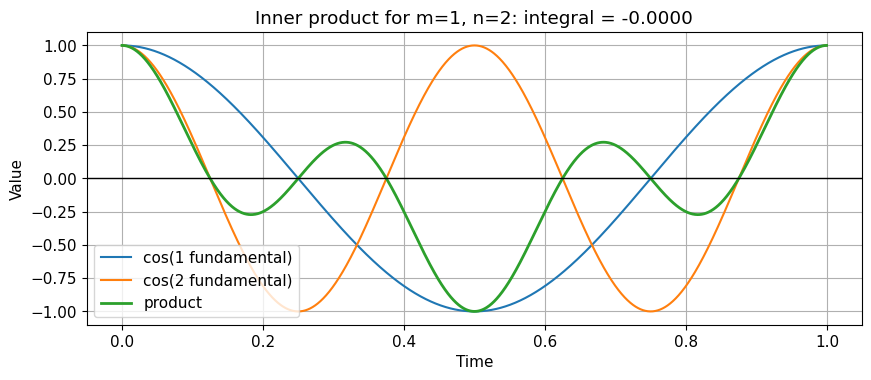

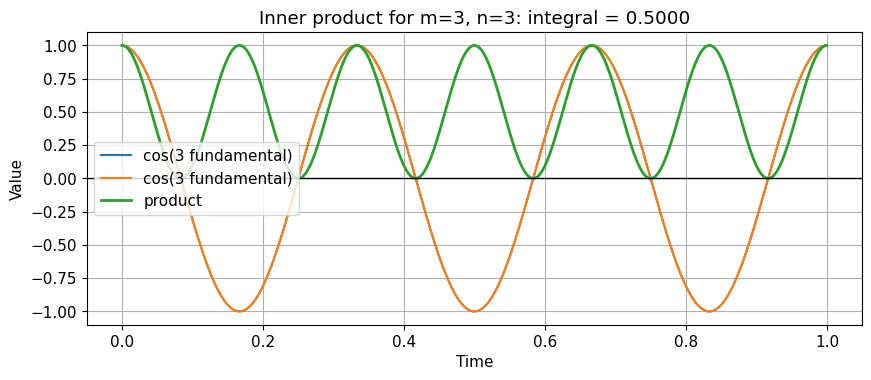

In [2]:
T = 1.0
N = 2000
t = np.linspace(0, T, N, endpoint=False)
dt = T/N

for m, n in [(1, 2), (3, 3)]:
    a = np.cos(2*np.pi*m*t/T)
    b = np.cos(2*np.pi*n*t/T)
    product = a*b
    integral = product.sum()*dt
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(t, a, label=f"cos({m} fundamental)")
    ax.plot(t, b, label=f"cos({n} fundamental)")
    ax.plot(t, product, label="product", linewidth=2)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Inner product for m={m}, n={n}: integral = {integral:.4f}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.legend()
    plt.show()

## Recover real Fourier coefficients

For a signal over one period $T$,

$$C_n = \frac{2}{T}\int_0^T f(t)\cos(2\pi nt/T)\,dt,$$

$$D_n = \frac{2}{T}\int_0^T f(t)\sin(2\pi nt/T)\,dt.$$

The amplitude and phase are

$$A_n = \sqrt{C_n^2 + D_n^2}, \qquad \phi_n = \arctan2(D_n, C_n).$$

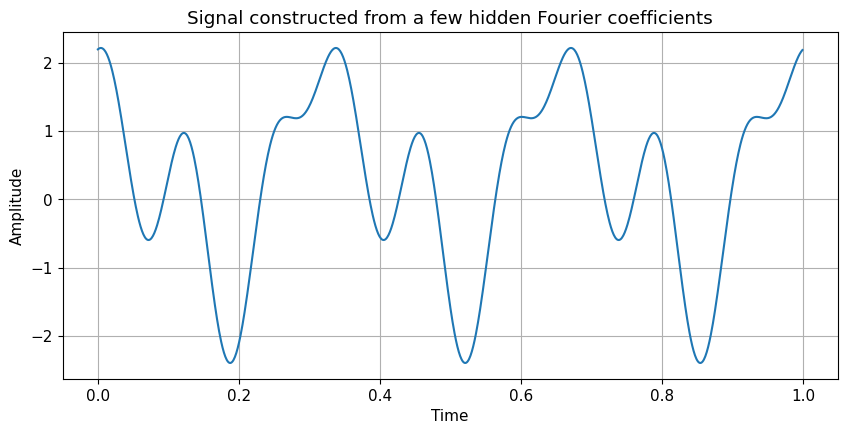

 n |  C true | C found |  D true | D found | amplitude | phase
---|---------|---------|---------|---------|-----------|-------
 0 |   0.600 |   0.600 |   0.000 |   0.000 |     0.600 |  0.000
 3 |   1.400 |   1.400 |   0.000 |  -0.000 |     1.400 | -0.000
 6 |   0.000 |  -0.000 |  -0.800 |  -0.800 |     0.800 | -1.571
 9 |   0.500 |   0.500 |   0.700 |   0.700 |     0.860 |  0.951


In [3]:
T = 1.0
N = 1024
t = np.arange(N) / N * T
nmax = 16

C_true = np.zeros(nmax+1)
D_true = np.zeros(nmax+1)
C_true[0] = 0.6         # constant term appears as C0/2 = 0.3
C_true[3] = 1.4
D_true[6] = -0.8
C_true[9] = 0.5
D_true[9] = 0.7

signal = C_true[0]/2 * np.ones_like(t)
for n in range(1, nmax+1):
    signal += C_true[n]*np.cos(2*np.pi*n*t/T) + D_true[n]*np.sin(2*np.pi*n*t/T)

C_hat = np.zeros(nmax+1)
D_hat = np.zeros(nmax+1)
C_hat[0] = 2*np.mean(signal)
for n in range(1, nmax+1):
    C_hat[n] = 2*np.mean(signal*np.cos(2*np.pi*n*t/T))
    D_hat[n] = 2*np.mean(signal*np.sin(2*np.pi*n*t/T))

A_hat = np.hypot(C_hat, D_hat)
phi_hat = np.arctan2(D_hat, C_hat)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t, signal)
ax.set_title("Signal constructed from a few hidden Fourier coefficients")
ax.set_xlabel("Time")
ax.set_ylabel("Amplitude")
plt.show()

print(" n |  C true | C found |  D true | D found | amplitude | phase")
print("---|---------|---------|---------|---------|-----------|-------")
for n in range(nmax+1):
    if abs(C_true[n]) > 1e-10 or abs(D_true[n]) > 1e-10 or A_hat[n] > 1e-10:
        print(f"{n:2d} | {C_true[n]:7.3f} | {C_hat[n]:7.3f} | {D_true[n]:7.3f} | {D_hat[n]:7.3f} | {A_hat[n]:9.3f} | {phi_hat[n]:6.3f}")

## Spectra from the recovered coefficients

The $C$ and $D$ spectra are two coordinate axes. The amplitude spectrum combines them into a length at each frequency.

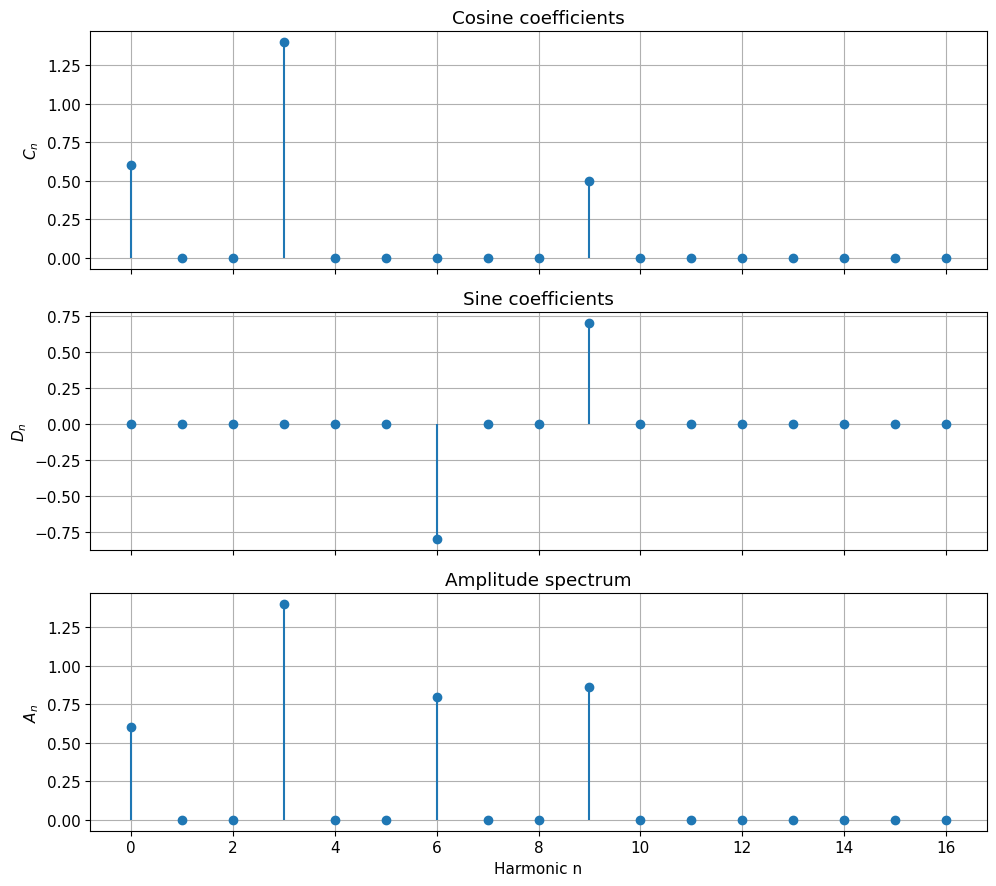

In [4]:
ns = np.arange(nmax+1)
fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
axs[0].stem(ns, C_hat, basefmt=" ")
axs[0].set_ylabel(r"$C_n$")
axs[0].set_title("Cosine coefficients")
axs[1].stem(ns, D_hat, basefmt=" ")
axs[1].set_ylabel(r"$D_n$")
axs[1].set_title("Sine coefficients")
axs[2].stem(ns, A_hat, basefmt=" ")
axs[2].set_ylabel(r"$A_n$")
axs[2].set_xlabel("Harmonic n")
axs[2].set_title("Amplitude spectrum")
plt.tight_layout()
plt.show()

## Projection scan

A frequency scan is just repeated projection. Here we project onto cosine waves for many candidate harmonics.

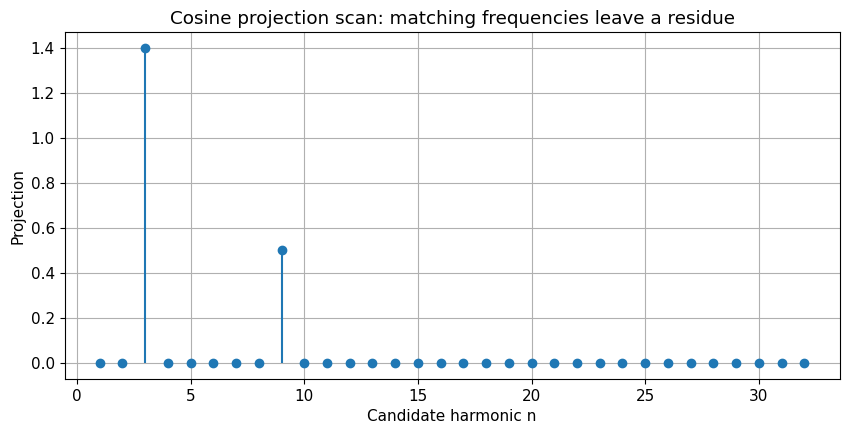

In [5]:
scan = []
for n in range(1, 33):
    detector = np.cos(2*np.pi*n*t/T)
    scan.append(2*np.mean(signal*detector))
scan = np.array(scan)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.stem(np.arange(1, 33), scan, basefmt=" ")
ax.set_title("Cosine projection scan: matching frequencies leave a residue")
ax.set_xlabel("Candidate harmonic n")
ax.set_ylabel("Projection")
plt.show()

## Checkpoint

1. Add a component at harmonic 12. Does the scan find it?
2. Why does the sine coefficient at harmonic 6 appear even though the cosine scan does not show it?
3. Change the interval so it no longer contains an integer number of periods. What happens to orthogonality?